# Прогнозирование цен на Toyota Corolla
В этом блокноте мы исследуем набор данных Toyota Corolla, чтобы построить модель регрессии, которая предсказывает цену автомобиля на основе различных характеристик.

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Загрузка и анализ данных
В этом разделе мы загружаем набор данных и проводим первичный осмотр признаков и типов данных.

In [7]:
df=pd.read_csv('/content/ToyotaCorolla.csv')
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non-null   int64 


In [9]:
df['Fuel_Type'].unique()
df['Color'].unique()

array(['Blue', 'Silver', 'Black', 'White', 'Grey', 'Red', 'Green',
       'Yellow', 'Violet', 'Beige'], dtype=object)

## Предобработка данных
Здесь мы обрабатываем категориальные переменные с помощью One-Hot Encoding и подготавливаем матрицу признаков `X` и целевой вектор `y`.

In [10]:
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Color']).drop(columns=['Id', 'Model'])
ohe_list=['Fuel_Type_'+i for i in df['Fuel_Type'].unique()]
ohe_list+=['Color_'+i for i in df['Color'].unique()]
df_encoded[ohe_list].sum()

,0
Fuel_Type_Diesel,155
Fuel_Type_Petrol,1264
Fuel_Type_CNG,17
Color_Blue,283
Color_Silver,122
Color_Black,191
Color_White,31
Color_Grey,301
Color_Red,278
Color_Green,220


<Axes: >

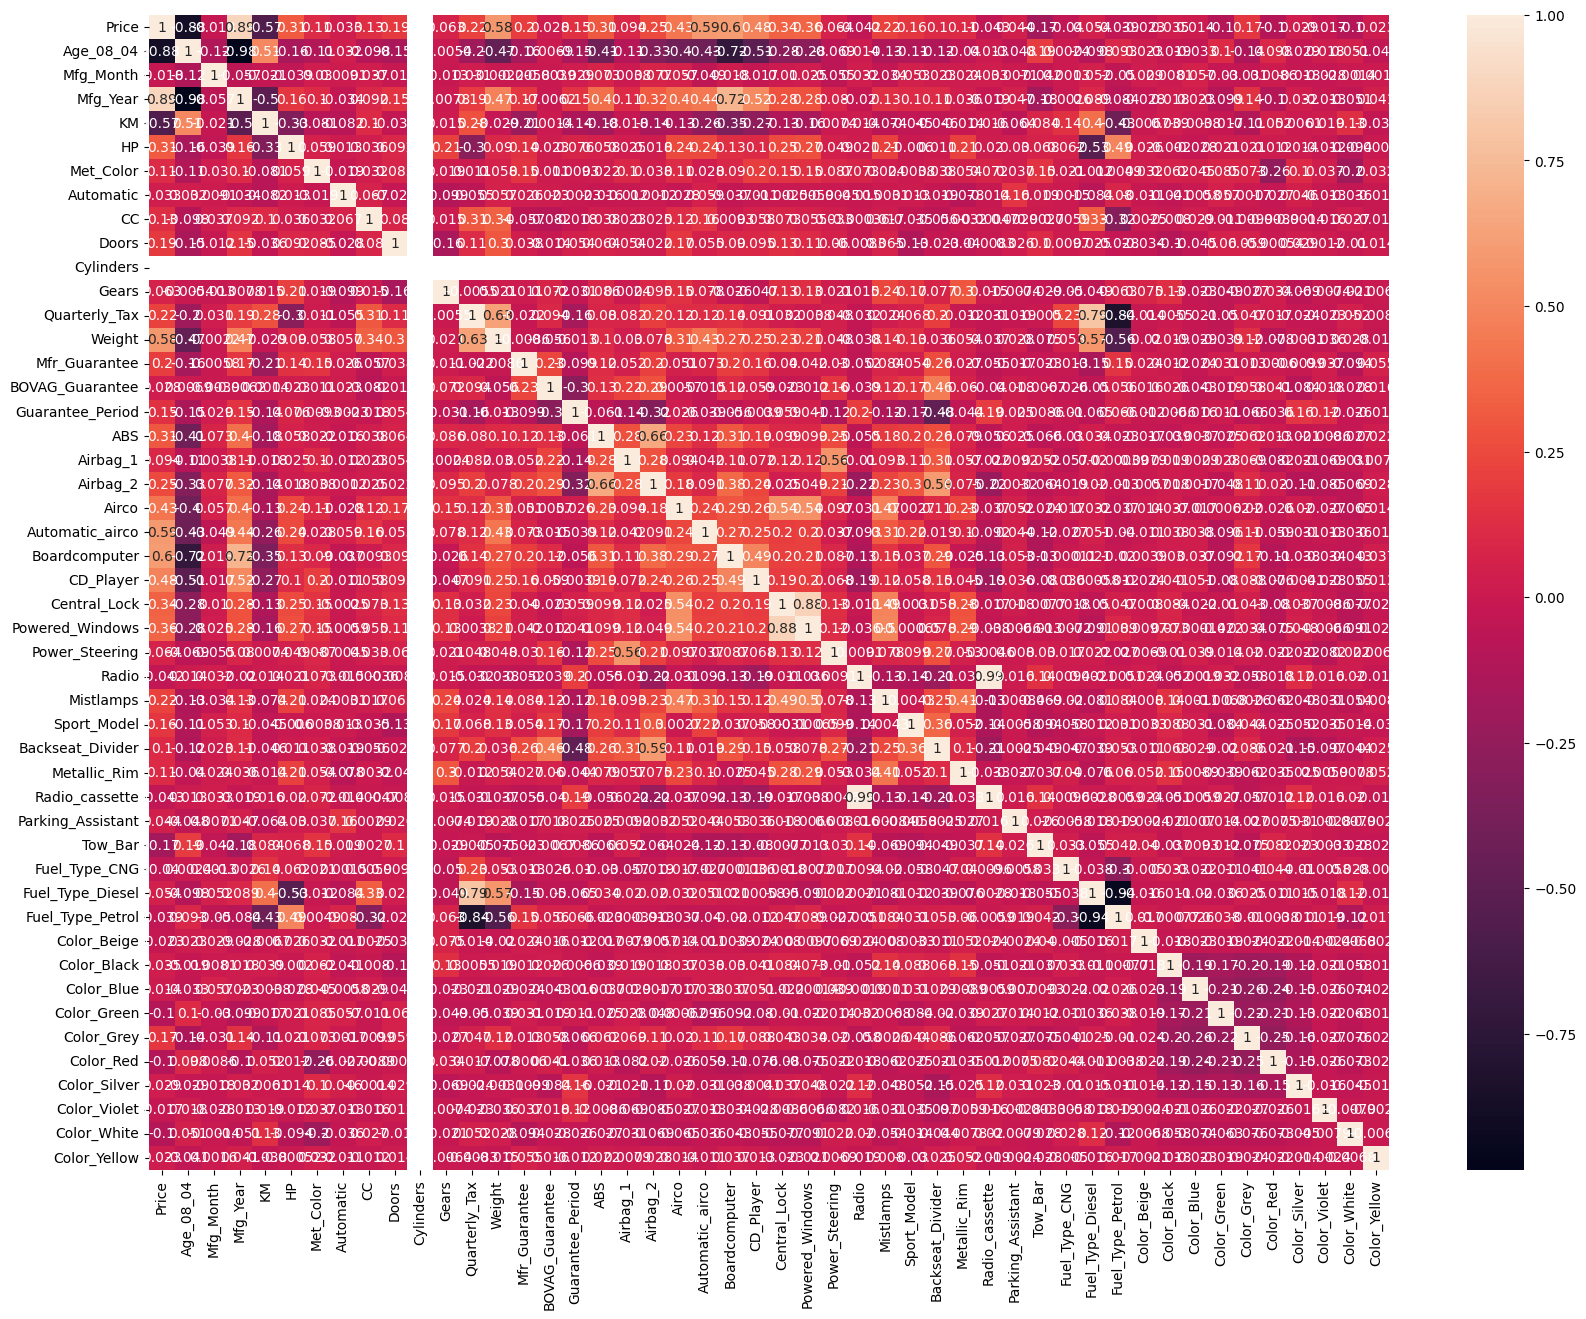

In [11]:
plt.figure(figsize=(20, 15))
sns.heatmap(df_encoded.corr(), annot=True)

In [12]:
df_encoded.corr()

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,...,Color_Beige,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
Price,1.000000,-0.876590,-0.018138,0.885159,-0.569960,0.314990,0.108905,0.033081,0.126389,0.185326,...,-0.022684,0.034896,0.014431,-0.104963,0.169947,-0.103803,0.028562,-0.016848,-0.103360,0.022726
Age_08_04,-0.876590,1.000000,-0.123255,-0.983661,0.505672,-0.156622,-0.108150,0.031717,-0.098084,-0.148359,...,0.023098,-0.019399,-0.032955,0.103530,-0.137660,0.098365,-0.028550,0.017916,0.050933,-0.040883
Mfg_Month,-0.018138,-0.123255,1.000000,-0.057416,-0.020630,-0.039312,0.030266,0.009146,0.037387,-0.012069,...,0.028902,0.008067,0.057279,-0.030403,-0.031214,0.008646,-0.017838,-0.028353,-0.001445,0.001609
Mfg_Year,0.885159,-0.983661,-0.057416,1.000000,-0.504974,0.164697,0.103310,-0.033567,0.091892,0.151442,...,-0.028480,0.018052,0.022763,-0.098638,0.144152,-0.100526,0.031958,-0.012880,-0.050977,0.040837
KM,-0.569960,0.505672,-0.020630,-0.504974,1.000000,-0.333538,-0.080503,-0.081854,0.102683,-0.036197,...,-0.006720,0.039012,-0.003840,-0.017439,-0.112194,0.052190,0.006113,0.018810,0.130403,-0.037995
HP,0.314990,-0.156622,-0.039312,0.164697,-0.333538,1.000000,0.058712,0.013144,0.035856,0.092424,...,0.025963,-0.002040,-0.027949,0.021242,0.021349,0.011700,0.014300,-0.012359,-0.093928,-0.000516
Met_Color,0.108905,-0.108150,0.030266,0.103310,-0.080503,0.058712,1.000000,-0.019335,0.031812,0.085243,...,0.031764,0.061789,0.044972,0.084797,0.072634,-0.261828,0.104902,0.036691,-0.203738,0.031764
Automatic,0.033081,0.031717,0.009146,-0.033567,-0.081854,0.013144,-0.019335,1.000000,0.066740,-0.027654,...,-0.011114,-0.041491,-0.005847,0.056846,0.001725,-0.026799,0.045772,-0.012837,-0.036079,-0.011114
CC,0.126389,-0.098084,0.037387,0.091892,0.102683,0.035856,0.031812,0.066740,1.000000,0.079903,...,0.002496,-0.007964,0.029421,-0.010579,-0.009867,-0.008865,-0.001351,-0.015804,0.027304,-0.011884
Doors,0.185326,-0.148359,-0.012069,0.151442,-0.036197,0.092424,0.085243,-0.027654,0.079903,1.000000,...,-0.033636,-0.099880,-0.044962,0.060186,0.059174,-0.000541,0.028644,0.012019,-0.010245,0.014409


### Отбор признаков и разделение выборки
После кодирования мы разделяем данные на обучающую и тестовую выборки для оценки качества модели на новых данных.

In [13]:
df_encoded.drop(columns=ohe_list, inplace=True)

In [14]:
X=df_encoded.drop(columns='Price').values
y=df_encoded['Price'].values
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1148, 34) (1148,) (288, 34) (288,)


## Построение модели
Мы используем Random Forest Regressor для моделирования зависимости между характеристиками автомобиля и его ценой.

In [19]:
from sklearn.ensemble import RandomForestRegressor
#from sklearn.model_selection import GridSearchCV
#param_grid={'n_estimators': np.linspace(100, 1100, 10, dtype=int), 'max_depth' : np.arange(3, 7, 1, dtype=int)}
#grid_random_forest=GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid)
#grid_random_forest.fit(X_train, y_train)
rnd_forest=RandomForestRegressor(n_estimators=877, max_depth=6, random_state=42)
rnd_forest.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, n_estimators=877, random_state=42)

## Оценка модели
Наконец, мы оцениваем модель, используя такие метрики, как $R^2$, среднеквадратичная ошибка (RMSE) и средняя абсолютная ошибка (MAE).

In [23]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
y_pred=rnd_forest.predict(X_test)
metrics=pd.Series({'r2_score': r2_score(y_test, y_pred), 'root_mean_squared_error': root_mean_squared_error(y_test, y_pred), 'mean_absolute_error': mean_absolute_error(y_test, y_pred)})
metrics

,0
r2_score,0.925921
root_mean_squared_error,994.195390
mean_absolute_error,764.839490


### Визуализация результатов
Давайте визуализируем, насколько близко предсказания модели находятся к реальным значениям цен.

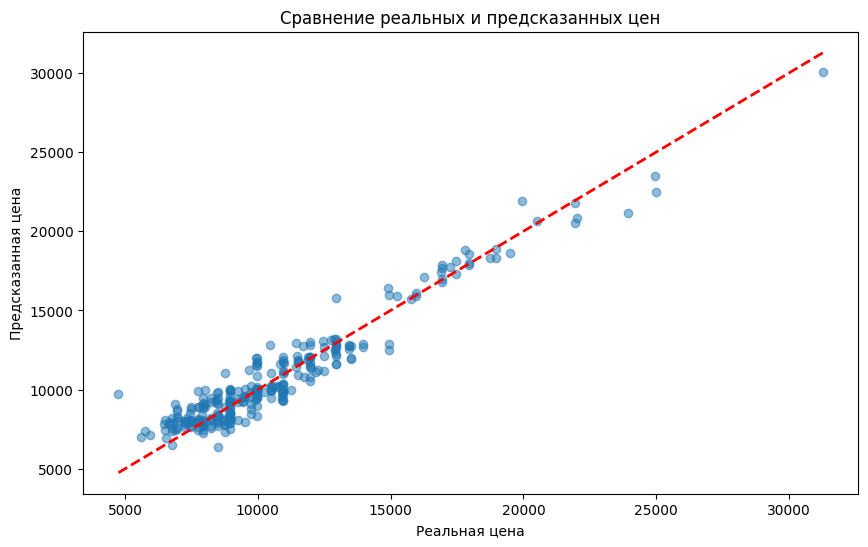

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Сравнение реальных и предсказанных цен')
plt.show()

### Анализ важности признаков
Понимание того, какие признаки наиболее важны, помогает интерпретировать работу модели.

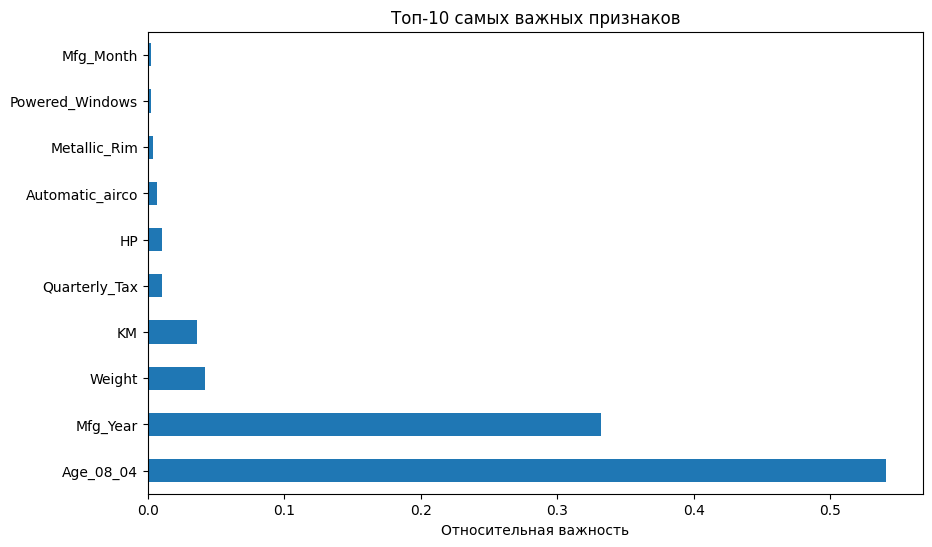

In [25]:
feature_importances = pd.Series(rnd_forest.feature_importances_, index=df_encoded.drop(columns='Price').columns)
feature_importances.nlargest(10).plot(kind='barh', figsize=(10, 6))
plt.title('Топ-10 самых важных признаков')
plt.xlabel('Относительная важность')
plt.show()